# Clustering: Does a Renewable Site Typology Emerge?

The EDA notebook hand-labeled 13 sites into 6 climate zones (Tell,
High Plateau, Saharan Atlas, ...). That labeling was based on
geography, not on the actual renewable-relevant behavior of each site.

This notebook asks the real question: **if we cluster purely on
resource strength, predictability, solar/wind complementarity, and heat
exposure, with no location information at all, do we recover the
same zones, or does a different, more decision-relevant grouping show
up?**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_theme(style="whitegrid")
import os
FIG_DIR = "../reports/figures"
os.makedirs(FIG_DIR, exist_ok=True)

df = pd.read_csv("../data/processed/site_summary_features.csv", index_col=0)
df

,ALLSKY_SFC_SW_DWN,ALLSKY_SFC_SW_DNI,WS10M,WS50M,T2M,mean_kt,std_kt,interannual_cv_pct,solar_wind_monthly_corr,hot_days_per_year,zone,lat,lon
name,,,,,,,,,,,,,
Annaba,4.765907,4.832540,4.356721,5.465376,19.287541,0.804659,0.199817,2.144124,-0.861481,0.15,Tell/Coastal,36.9000,7.7667
Algiers,4.853028,5.179117,4.957277,5.872943,19.232717,0.818600,0.196913,2.353181,-0.739837,0.00,Tell/Coastal,36.7538,3.0588
Oran,5.044527,5.447002,4.088864,5.488416,18.775303,0.850580,0.169959,1.917852,-0.771772,0.15,Tell/Coastal,35.6969,-0.6331
Batna,5.012807,4.992734,3.505587,4.956921,13.848428,0.828687,0.170152,1.863847,-0.502090,0.00,High Plateau,35.5559,6.1742
Tiaret,5.024751,5.154229,3.967644,5.556292,16.802693,0.826906,0.191285,2.173019,-0.831534,0.20,High Plateau,35.3711,1.3170
Djelfa,5.415605,5.605542,4.646014,6.420157,15.845203,0.875664,0.146544,1.390321,-0.452069,0.00,High Plateau,34.6667,3.2500
Laghouat,5.628343,5.834539,4.407530,6.228834,18.016979,0.902660,0.128249,1.130404,-0.335701,1.20,Saharan Atlas,33.8000,2.8646
El Bayadh,5.583426,5.781540,4.648459,6.412141,15.983336,0.891370,0.136096,1.468081,-0.211949,0.00,Saharan Atlas,33.6803,1.0197
Ghardaia,5.789548,6.001451,4.305238,6.184274,20.793518,0.932310,0.111008,0.822755,0.063929,15.85,Northern Sahara,32.4909,3.6738


## 1. Feature selection

Deliberately **excluding lat/lon and zone** from the clustering
features, since those are the labels we're testing against, not inputs.
Also dropping features that are near-duplicates of another one already
in the set (WS10M vs. WS50M; DNI vs. DWN). Kept the hub-height wind
speed and the flat-panel-relevant GHI since flat-panel PV is the more
likely near-term Algerian deployment vs. CSP.

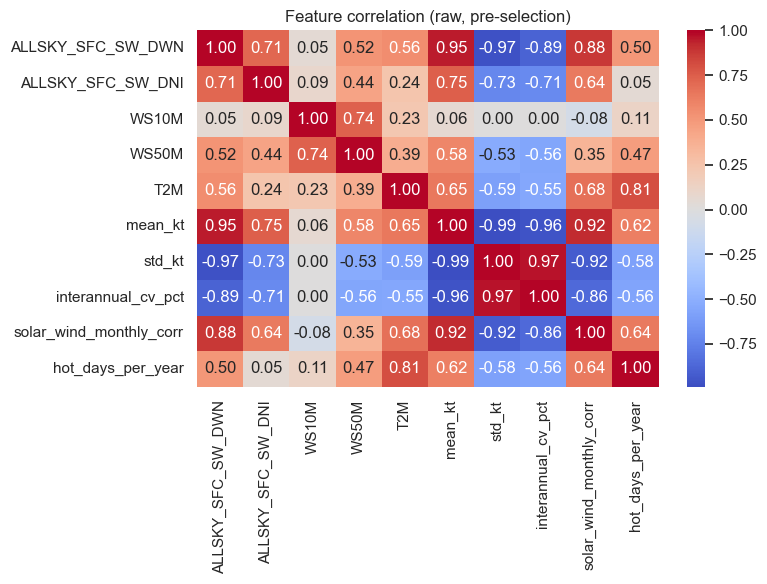

In [2]:
corr = df[
    ["ALLSKY_SFC_SW_DWN", "ALLSKY_SFC_SW_DNI", "WS10M", "WS50M", "T2M",
     "mean_kt", "std_kt", "interannual_cv_pct", "solar_wind_monthly_corr",
     "hot_days_per_year"]
].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature correlation (raw, pre-selection)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/clustering_feature_correlation.png", dpi=150)
plt.show()

In [3]:
FEATURES = [
    "ALLSKY_SFC_SW_DWN",       # resource strength
    "WS50M",                  # wind resource strength
    "mean_kt",                # predictability (clearness)
    "interannual_cv_pct",     # year-to-year stability
    "solar_wind_monthly_corr",# hybrid hedging value
    "hot_days_per_year",      # PV heat-derating risk
]
X = df[FEATURES].copy()
X_scaled = StandardScaler().fit_transform(X)
pd.DataFrame(X_scaled, index=X.index, columns=X.columns).round(2)

,ALLSKY_SFC_SW_DWN,WS50M,mean_kt,interannual_cv_pct,solar_wind_monthly_corr,hot_days_per_year
name,,,,,,
Annaba,-1.46,-0.94,-1.54,1.24,-1.18,-0.50
Algiers,-1.29,-0.05,-1.27,1.62,-0.98,-0.51
Oran,-0.90,-0.88,-0.66,0.83,-1.03,-0.50
Batna,-0.96,-2.04,-1.08,0.73,-0.57,-0.51
Tiaret,-0.94,-0.74,-1.11,1.29,-1.13,-0.50
Djelfa,-0.14,1.15,-0.18,-0.13,-0.49,-0.51
Laghouat,0.29,0.73,0.34,-0.60,-0.29,-0.46
El Bayadh,0.20,1.13,0.13,0.01,-0.08,-0.51
Ghardaia,0.62,0.63,0.92,-1.15,0.39,0.14


## 2. How many clusters? Hierarchical dendrogram + k-means diagnostics

With only 13 sites, a dendrogram is more informative than committing to
a k up front. It shows the actual merge structure so we can pick a
defensible cut point, and we cross-check against k-means inertia/
silhouette.

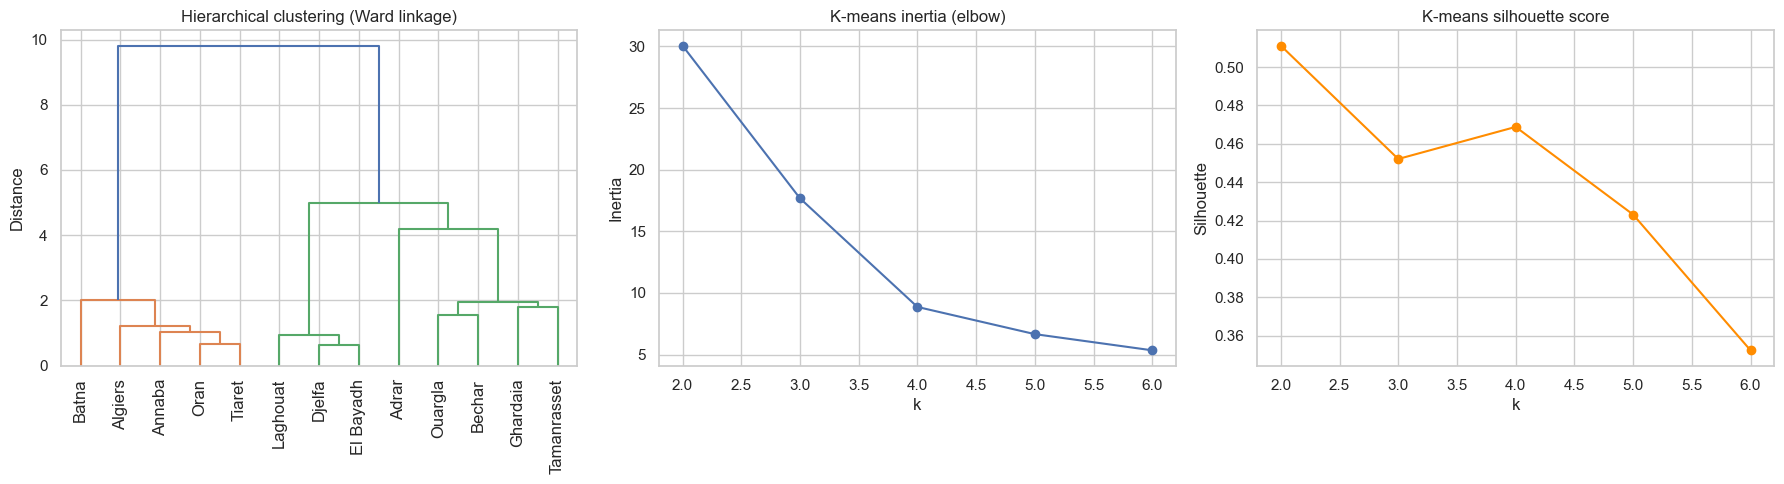

Silhouette by k: {2: 0.511, 3: 0.452, 4: 0.469, 5: 0.423, 6: 0.352}


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

Z = linkage(X_scaled, method="ward")
dendrogram(Z, labels=X.index.tolist(), ax=axes[0], leaf_rotation=90)
axes[0].set_title("Hierarchical clustering (Ward linkage)")
axes[0].set_ylabel("Distance")

inertias, silhouettes = [], []
k_range = range(2, 7)
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

axes[1].plot(list(k_range), inertias, marker="o")
axes[1].set_title("K-means inertia (elbow)")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Inertia")

axes[2].plot(list(k_range), silhouettes, marker="o", color="darkorange")
axes[2].set_title("K-means silhouette score")
axes[2].set_xlabel("k")
axes[2].set_ylabel("Silhouette")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/cluster_selection_diagnostics.png", dpi=150)
plt.show()

print("Silhouette by k:", dict(zip(k_range, [round(s, 3) for s in silhouettes])))

Silhouette actually peaks at **k=2** (0.511) and decreases monotonically
after that (0.452, 0.469, 0.423, 0.352 for k=3..6). k=2 is the
"cleanest" split by that metric, but it just separates "coast/plateau"
from "everything in or near the Sahara," which is the geographic
gradient we already knew about from the EDA.

**We choose k=4 instead**, accepting the small silhouette cost
(0.469 vs. 0.511), because it's the smallest k that isolates two
distinctions that matter for the siting question and that k=2/k=3
collapse:
- **Adrar splits off as its own singleton cluster.** Its extreme heat
  exposure (87 hot-days/yr) makes it behave differently from the other
  high-resource Saharan sites even though its solar/wind numbers are
  similar to theirs.
- **A distinct transition cluster (Djelfa, Laghouat, El Bayadh)**
  separates from both the coastal/plateau group and the deep-Sahara
  group, rather than being absorbed into one of them.

This is a judgment call, not a mechanical "pick the max silhouette,"
worth stating explicitly rather than quietly picking k=4 and only
reporting the diagnostic that supports it.

In [5]:
K = 4

hier = AgglomerativeClustering(n_clusters=K, linkage="ward").fit(X_scaled)
km = KMeans(n_clusters=K, n_init=10, random_state=0).fit(X_scaled)

df["cluster_hier"] = hier.labels_
df["cluster_kmeans"] = km.labels_

pd.crosstab(df["cluster_hier"], df["cluster_kmeans"])

cluster_kmeans,0,1,2,3
cluster_hier,,,,
0,0,5,0,0
1,4,0,0,0
2,0,0,3,0
3,0,0,0,1


## 3. Do the clusters line up with the hand-labeled zones?

In [6]:
pd.crosstab(df["zone"], df["cluster_hier"])

cluster_hier,0,1,2,3
zone,,,,
Central Sahara,0,0,0,1
Deep South Sahara,0,1,0,0
High Plateau,2,0,1,0
Northern Sahara,0,2,0,0
Saharan Atlas,0,0,2,0
Tell/Coastal,3,0,0,0
Western Sahara,0,1,0,0


They mostly do, with one specific mismatch worth calling out:
**Djelfa** is hand-labeled "High Plateau" (like Batna and Tiaret), but
it clusters with the Saharan Atlas sites (Laghouat, El Bayadh) instead.
Its clearness index, interannual stability, and complementarity
profile behave more like the Saharan-Atlas transition zone than like
the other two Plateau sites. The hand-drawn zone boundary between
"High Plateau" and "Saharan Atlas" doesn't line up with actual climate
behavior at Djelfa specifically. Everything else falls in line with
the zones we'd expect: Tell + rest of the Plateau together, and the
four highest-resource Saharan sites (Ghardaïa, Ouargla, Béchar,
Tamanrasset) together, with Adrar pulled out on its own by heat
exposure alone.

## 4. PCA projection: clusters vs. original zones, side by side

Explained variance ratio: [0.752 0.122]


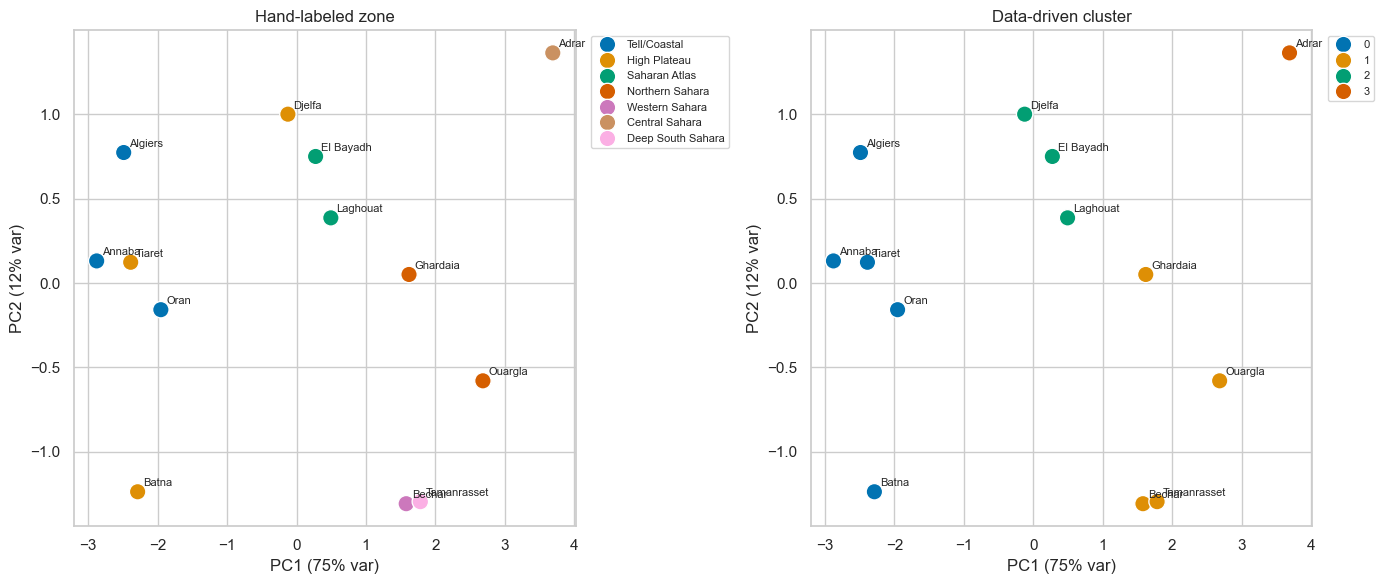

In [7]:
pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)
df["pc1"], df["pc2"] = coords[:, 0], coords[:, 1]
print("Explained variance ratio:", pca.explained_variance_ratio_.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, hue_col, title in zip(axes, ["zone", "cluster_hier"], ["Hand-labeled zone", "Data-driven cluster"]):
    sns.scatterplot(
        data=df, x="pc1", y="pc2", hue=hue_col, s=140, ax=ax, palette="colorblind"
    )
    for name, row in df.iterrows():
        ax.annotate(name, (row["pc1"], row["pc2"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
    ax.set_title(title)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.0f}% var)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.0f}% var)")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/pca_clusters_vs_zones.png", dpi=150)
plt.show()

## 5. Cluster profiles

Mean of each raw (unscaled) feature per cluster: this is what actually
gets described in the write-up, not the standardized values.

In [8]:
profile = df.groupby("cluster_hier")[FEATURES].mean().round(2)
profile["n_sites"] = df.groupby("cluster_hier").size()
profile["sites"] = df.groupby("cluster_hier").apply(lambda g: ", ".join(g.index), include_groups=False)
profile

,ALLSKY_SFC_SW_DWN,WS50M,mean_kt,interannual_cv_pct,solar_wind_monthly_corr,hot_days_per_year,n_sites,sites
cluster_hier,,,,,,,,
0,4.94,5.47,0.83,2.09,-0.74,0.10,5,"Annaba, Algiers, Oran, Batna, Tiaret"
1,5.98,5.89,0.94,0.92,0.50,17.96,4,"Ghardaia, Ouargla, Bechar, Tamanrasset"
2,5.54,6.35,0.89,1.33,-0.33,0.40,3,"Djelfa, Laghouat, El Bayadh"
3,6.08,6.64,0.95,0.88,0.57,87.25,1,Adrar


## Four renewable siting profiles

**Cluster 0, Coast & Plateau, hybrid hedge** (Annaba, Algiers, Oran,
Batna, Tiaret): moderate resource (GHI 4.94, kt 0.83), the weakest
year-to-year stability of the four (CV 2.09%), but by far the
strongest solar/wind hedge (corr −0.74). **Best case: hybrid solar+wind
where the goal is reducing seasonal variability, not maximizing raw
output.**

**Cluster 1, Deep Sahara, high resource & aligned** (Ghardaïa,
Ouargla, Béchar, Tamanrasset): strong resource (GHI 5.98, kt 0.94),
very stable year to year (CV 0.92%), but solar and wind now move
*together* (corr +0.50) and moderate heat exposure appears (~18
hot-days/yr). **Best case: large solar-only builds. A hybrid plant
here adds capacity, not risk reduction.**

**Cluster 2, Saharan Atlas transition** (Djelfa, Laghouat, El
Bayadh): resource and stability sit between clusters 0 and 1, complementarity
is still moderately negative (−0.33, a partial hedge), and it
actually has the **highest mean wind speed of any non-outlier cluster**
(6.35 m/s at 50m, above even the deep-Sahara cluster's 5.89). That's a
genuinely non-obvious result: on the wind axis alone, this
"in-between" zone outperforms the flagship desert sites. **Best case:
worth a dedicated wind-resource look, not just a leftover
transition zone.**

**Cluster 3, Adrar, heat-risk outlier** (singleton): the strongest raw
resource of all 13 sites (GHI 6.08, kt 0.95, most stable at CV 0.88%)
undercut by extreme heat exposure (87 hot-days/yr, 5x the next
highest cluster). **Best case: excellent resource on paper, but not a
safe pick without a real PV-derating and thermal-management analysis
first.** Exactly the kind of site a resource map alone would rank #1
and a siting study would catch before committing capital.